# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [25]:
ПІБ = 'Білоусов Михайло'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 1     # ваш номер за списком групи

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [26]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Білоусов Михайло, ШІ-32, варіант 1
ваш потік:                   P>50
ваша пара для графіка 3:     швидкість вітру та потік P>10
ваш агрегат для етапу 4:     медіана
ваше додаткове питання:      Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [27]:
!uv add pandas numpy matplotlib openpyxl

  × No solution found when resolving dependencies for split (markers:               
  │ python_full_version >= '3.14' and sys_platform == 'win32'):
  ╰─▶ Because xelatex was not found in the package registry and your project
      depends on xelatex, we can conclude that your project's requirements
      are unsatisfiable.

      hint: While the active Python version is 3.13, the resolution failed for
      other Python versions supported by your project. Consider limiting your
      project's supported Python versions using `requires-python`.
  help: If you want to add the package regardless of the failed resolution,
        provide the `--frozen` flag to skip locking and syncing.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [29]:
# ВАШ КОД
pd.read_excel(ФАЙЛ)

,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7220,NaN,2017,9,21,2335,58017,84900,21.9,0.361,0.202,0.084,0.0717,0.0475,143000,32900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7221,NaN,2017,9,21,2340,58017,85200,14.1,0.343,0.309,0.118,0.0679,0.0328,143000,32100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7222,NaN,2017,9,21,2345,58017,85500,27.1,0.465,0.237,0.106,0.0593,0.0251,140000,32500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7223,NaN,2017,9,21,2350,58017,85800,23.7,0.36,0.205,0.127,0.091,0.0363,140000,32700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*

Це пов'язано з тим, що читання просто виводить всю таблицю без перевірки на заголовки і т.д., просто сирі дані. Також воно приймає перший рядоу за заголовок, що відключається через задання параметра `header`.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [30]:
# ВАШ КОД
RAW = pd.read_excel(ФАЙЛ, header=None)

print(len(RAW))
RAW[:30]

7226


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [31]:
# ВАШ КОД
RAW.notna().sum()

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64

**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

3 таблиці, перша стовпці (від нуля) 1-14, друга 16-19, третя 24-31

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [32]:
# A
RAW.iloc[:30, 1:14]

,1,2,3,4,5,6,7,8,9,10,11,12,13
0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# B
RAW.iloc[:30, 16:20]

,16,17,18,19
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [34]:
# C
RAW.iloc[:30, 24:32]

,24,25,26,27,28,29,30,31
0,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці вимірювання |
|---|---|---|
| A | ftp://ftp.swpc.noaa.gov/pub/lists/particle/20170901_Gs_part_5m.txt | Protons/cm^2\*s\*sr, Electrons/cm2-s-sr |
| B | ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt | Radio flux 10.7 (sfu) |
| C | http://umtof.umd.edu/pm/crn/ | Proton speed [km/sec], Proton density [protons/cm^3] |


---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [35]:
# ВАШ КОД
A = RAW.iloc[26:, 1:15]
B = RAW.iloc[27:, 16:20]
C = RAW.iloc[27:, 26:32]
A = A.loc[:A.last_valid_index()].convert_dtypes()
B = B.loc[:B.last_valid_index()].convert_dtypes()
C = C.loc[:C.last_valid_index()].convert_dtypes()

A.columns = RAW.iloc[23:26, 1:15].fillna("").astype(str).agg(' '.join, axis=0)
A.columns = ["year", "month", "day", "HHMM"] + [i.lstrip() for i in list(A.columns[4:])]
B.columns = ["year"] + list(RAW.iloc[26, 17:20])
C.columns = ["year", "month", "day", "hour"] + list(RAW.iloc[26, 30:32])

### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [36]:
# ВАШ КОД
A["hour"] = A['HHMM'] // 100
A["minute"] = A['HHMM'] % 100
A["ts"] = pd.to_datetime(A[['year', 'month', 'day', 'hour', 'minute']])

B["ts"] = pd.to_datetime(B[['year', 'Month', 'Date']].rename(
        columns={ 
            'Month': 'month', 
            'Date': 'day'
        }))

C.loc[C["year"] < 100, "year"] += 2000
C["ts"] = pd.to_datetime(C[['year', 'month', 'day', 'hour']])

for n, i in (('A', A), ('B', B), ('C', C)):
    print(f'Table {n}: min {min(i["ts"])}, max {max(i["ts"])}')

Table A: min 2017-08-28 00:00:00, max 2017-09-21 23:55:00
Table B: min 2017-08-28 00:00:00, max 2017-09-21 00:00:00
Table C: min 2017-08-28 00:00:00, max 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [37]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [38]:
# ВАШ КОД
for n, i in (('A', A), ('B', B), ('C', C)):
    print(f'=== {n} ===')
    print(f'Length = {len(i)}')
    print('Dtypes:')
    print(i.dtypes)
    print('Count of NAs per col:')
    print(i.isna().sum())
    print(f'Count of full duplicates: {i.duplicated().sum()}')
    print('Describe:')
    print(i.describe())

=== A ===
Length = 7200
Dtypes:
year                            Int64
month                           Int64
day                             Int64
HHMM                            Int64
Modified Julian Day             Int64
Seconds of the Day              Int64
P > 1                         Float64
P > 5                         Float64
P >10                         Float64
P >30                         Float64
P >50                         Float64
P>100                         Float64
E>0.8                         Float64
E>2.0                         Float64
hour                            Int64
minute                          Int64
ts                     datetime64[us]
dtype: object
Count of NAs per col:
year                   0
month                  0
day                    0
HHMM                   0
Modified Julian Day    0
Seconds of the Day     0
P > 1                  3
P > 5                  3
P >10                  3
P >30                  3
P >50                  3
P>100      

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [39]:
# ВАШ КОД
print('=== BEFORE ===')
print('Describe:')
print(C.describe())
print('Speed negative:')
print(C.loc[C['SPEED'] < 0])
print(f'Count: {len(C.loc[C['SPEED'] < 0])}')
print('Density negative:')
print(C.loc[C['DENSITY'] < 0])
print(f'Count: {len(C.loc[C['DENSITY'] < 0])}')

C['SPEED'] = C['SPEED'].mask(C['SPEED'] < 0)
C['DENSITY'] = C['DENSITY'].mask(C['DENSITY'] < 0)

print('=== AFTER ===')
print('Describe:')
print(C.describe())
print('Speed negative:')
print(C.loc[C['SPEED'] < 0])
print(f'Count: {len(C.loc[C['SPEED'] < 0])}')
print('Density negative:')
print(C.loc[C['DENSITY'] < 0])
print(f'Count: {len(C.loc[C['DENSITY'] < 0])}')

=== BEFORE ===
Describe:
         year     month        day       hour       SPEED   DENSITY                   ts
count   601.0     601.0      601.0      601.0       601.0     601.0                  601
mean   2017.0  8.840266  13.973378  11.480865  506.547421  2.907654  2017-09-09 12:00:00
min    2017.0       8.0        1.0        0.0        -1.0      -1.0  2017-08-28 00:00:00
25%    2017.0       9.0        7.0        5.0       447.0       1.8  2017-09-03 06:00:00
50%    2017.0       9.0       13.0       11.0       517.0       2.4  2017-09-09 12:00:00
75%    2017.0       9.0       19.0       17.0       584.0       3.4  2017-09-15 18:00:00
max    2017.0       9.0       31.0       23.0       806.0      31.7  2017-09-22 00:00:00
std       0.0  0.366664      8.781   6.938063  125.073291  2.637873                  NaN
Speed negative:
     year  month  day  hour  SPEED  DENSITY                  ts
202  2017      9    4     7     -1     -1.0 2017-09-04 07:00:00
203  2017      9    4     8   

**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*

Таких значень 8, вони згруповані між собою в часі (4 вересня від 7 до 14 год) і мають обидва значення -1, що може свідчити про те, що вимірювальне обладнання в той час не працювало

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [40]:
# ВАШ КОД
A.describe()


,year,month,day,HHMM,Modified Julian Day,Seconds of the Day,P > 1,P > 5,P >10,P >30,P >50,P>100,E>0.8,E>2.0,hour,minute,ts
count,7200.0,7200.0,7200.0,7200.0,7200.0,7200.0,7197.0,7197.0,7197.0,7197.0,7197.0,7197.0,7197.0,7197.0,7200.0,7200.0,7200
mean,2017.0,8.84,13.96,1177.5,58005.0,43050.0,689.325064,156.626057,76.47402,18.838604,7.44684,1.65929,81862.741801,11401.502123,11.5,27.5,2017-09-09 11:57:30
min,2017.0,8.0,1.0,0.0,57993.0,0.0,0.429,0.151,0.117,0.0576,0.0455,0.0224,4.3,0.133,0.0,0.0,2017-08-28 00:00:00
25%,2017.0,9.0,7.0,588.75,57999.0,21525.0,11.7,0.279,0.186,0.0984,0.0597,0.0263,22200.0,552.0,5.75,13.75,2017-09-03 05:58:45
50%,2017.0,9.0,13.0,1177.5,58005.0,43050.0,55.4,0.632,0.376,0.146,0.0866,0.0363,68600.0,4290.0,11.5,27.5,2017-09-09 11:57:30
75%,2017.0,9.0,19.0,1766.25,58011.0,64575.0,560.0,107.0,35.8,0.99,0.249,0.067,143000.0,14100.0,17.25,41.25,2017-09-15 17:56:15
max,2017.0,9.0,31.0,2355.0,58017.0,86100.0,32500.0,2890.0,1330.0,399.0,191.0,61.5,259000.0,110000.0,23.0,55.0,2017-09-21 23:55:00
std,0.0,0.366632,8.775483,692.481902,7.211603,24943.113498,1625.968447,390.921861,222.362627,67.265595,28.620524,7.15889,65728.005824,16920.617446,6.922667,17.261461,NaN


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Часові значення (рік, місяць і т.д.), бо вони не описують змінну величину, а лише визначають час вимірювання

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [41]:
# ВАШ КОД
A = A.set_index("ts")
A_h = A.resample("1h").agg(["mean", "max"])
A = A.reset_index()
A_h

year       month       day        HHMM       Modified Julian Day        Seconds of the Day             P > 1           P > 5            P >10            P >30          \
                       mean   max  mean max  mean max    mean   max                mean    max               mean    max       mean   max      mean    max      mean    max      mean     max   
ts                                                                                                                                                                                              
2017-08-28 00:00:00  2017.0  2017   8.0   8  28.0  28    27.5    55             57993.0  57993             1650.0   3300   9.778333  19.4  0.324917   0.69  0.192917  0.314   0.09885   0.224   
2017-08-28 01:00:00  2017.0  2017   8.0   8  28.0  28   127.5   155             57993.0  57993             5250.0   6900   7.994167  13.6  0.291667  0.512  0.156583  0.259  0.072583  0.0919   
2017-08-28 02:00:00  2017.0  2017   8.0   8  28.0  28   227.5   255             57993.0  57993             8850.0  10500   6.099167  10.8     0.283  0.479  0.177667  0.321   0.08445   0.121   
2017-08-28 03:00:00  2017.0  2017   8.0   8  28.0  28   327.5   355             57993.0  57993            12450.0  14100     4.7525  7.76  0.236833  0.329  0.166333  0.244  0.087658    0.18   
2017-08-28 04:00:00  2017.0  2017   8.0   8  28.0  28   427.5   455             57993.0  57993            16050.0  17700   4.158333  6.62  0.334917  0.539  0.208333  0.309    0.0848   0.153   
...                     ...   ...   ...  ..   ...  ..     ...   ...                 ...    ...                ...    ...        ...   ...       ...    ...       ...    ...       ...     ...   
2017-09-21 19:00:00  2017.0  2017   9.0   9  21.0  21  1927.5  1955             58017.0  58017            70050.0  71700  63.166667  93.1    0.3725  0.795  0.229833  0.472  0.110642   0.157   
2017-09-21 20:00:00  2017.0  2017   9.0   9  21.0  21  2027.5  2055             58017.0  58017            73650.0  75300    42.1025  78.9    0.3975  0.833  0.226833  0.429  0.089325   0.138   
2017-09-21 21:00:00  2017.0  2017   9.0   9  21.0  21  2127.5  2155             58017.0  58017            77250.0  78900  50.783333  71.7   0.48925  0.788  0.317583  0.501  0.121358   0.204   
2017-09-21 22:00:00  2017.0  2017   9.0   9  21.0  21  2227.5  2255             58017.0  58017            80850.0  82500       39.0  48.8      0.35  0.536   0.20025   0.31  0.094358   0.143   
2017-09-21 23:00:00  2017.0  2017   9.0   9  21.0  21  2327.5  2355             58017.0  58017            84450.0  86100     28.825  42.1     0.465  0.861  0.257833  0.506  0.113575   0.168   

                        P >50             P>100                  E>0.8                   E>2.0           hour     minute      
                         mean     max      mean     max           mean       max          mean      max  mean max   mean max  
ts                                                                                                                            
2017-08-28 00:00:00  0.077583   0.178  0.040692  0.0793   20941.666667   23600.0   1011.583333   1180.0   0.0   0   27.5  55  
2017-08-28 01:00:00    0.0587  0.0798   0.02995  0.0471   18091.666667   20600.0         713.0    907.0   1.0   1   27.5  55  
2017-08-28 02:00:00  0.069642   0.111  0.035025  0.0595   14108.333333   15000.0    380.833333    475.0   2.0   2   27.5  55  
2017-08-28 03:00:00  0.068092   0.139  0.035517  0.0818   12766.666667   13100.0    267.916667    284.0   3.0   3   27.5  55  
2017-08-28 04:00:00   0.07285   0.142  0.039708  0.0694   11333.333333   12300.0         203.0    234.0   4.0   4   27.5  55  
...                       ...     ...       ...     ...            ...       ...           ...      ...   ...  ..    ...  ..  
2017-09-21 19:00:00    0.0743   0.105  0.040192  0.0687       180250.0  186000.0       65750.0  66800.0  19.0  19   27.5  55  
2017-09-21 20:00:00  0.069983   0.105  0.039692  0

### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

In [42]:
# ВАШ КОД
A = A.set_index("ts")
A_h_my = A["P >50"].iloc[:24*12].resample("1h").agg(["median", "mean"])
A = A.reset_index()
A_h_my

,median,mean
ts,,
2017-08-28 00:00:00,0.0613,0.077583
2017-08-28 01:00:00,0.05315,0.0587
2017-08-28 02:00:00,0.06275,0.069642
2017-08-28 03:00:00,0.05795,0.068092
2017-08-28 04:00:00,0.06155,0.07285
2017-08-28 05:00:00,0.05565,0.063692
2017-08-28 06:00:00,0.067,0.066992
2017-08-28 07:00:00,0.0635,0.076817
2017-08-28 08:00:00,0.0727,0.074467


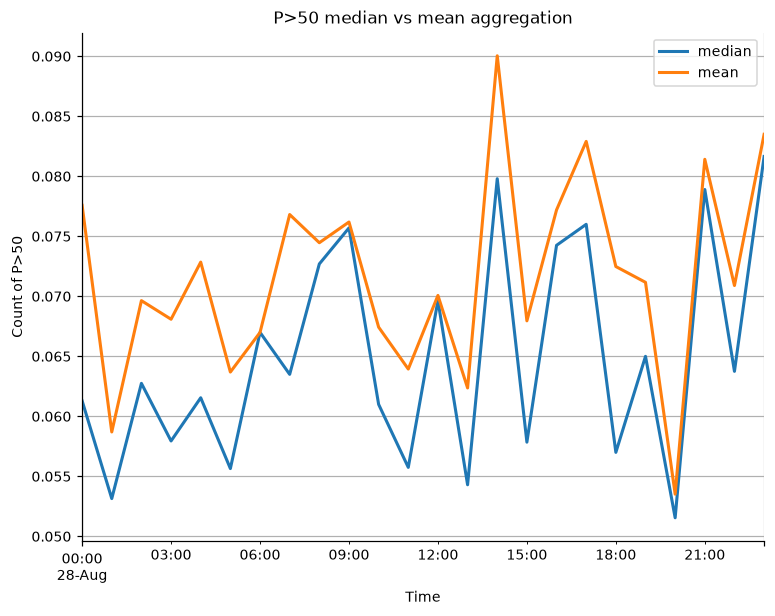

In [43]:
A_h_my.plot(figsize=[8,6], linewidth=2)

plt.title("P>50 median vs mean aggregation")
plt.xlabel('Time')
plt.ylabel('Count of P>50')
plt.grid(True)
plt.show()

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

Криві відрізняються досить суттєво (середнє значення скрізь більше). Це може свідчити про те, що були наявні спалахи кількості частинок у деякі 5-хвилинні періоди, або про те, що розподіл не є нормальним у будь-якому іншому сенсі цього слова.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [44]:
# ВАШ КОД
B = B.set_index("ts")
B_h = B.resample("1h").ffill()
B = B.reset_index()

C_h = C.set_index("ts")
M = pd.concat([A_h, B_h, C_h], axis=1, join="outer").fillna(0)
M = M[['SPEED', 'DENSITY', 'Radio Flux 10.7'] + [i for i in M.columns if i[0].startswith('P') or i[0].startswith('E')]]
M


,SPEED,DENSITY,Radio Flux 10.7,"(P > 1, mean)","(P > 1, max)","(P > 5, mean)","(P > 5, max)","(P >10, mean)","(P >10, max)","(P >30, mean)","(P >30, max)","(P >50, mean)","(P >50, max)","(P>100, mean)","(P>100, max)","(E>0.8, mean)","(E>0.8, max)","(E>2.0, mean)","(E>2.0, max)"
ts,,,,,,,,,,,,,,,,,,,
2017-08-28 00:00:00,285,3.0,82,9.778333,19.4,0.324917,0.69,0.192917,0.314,0.09885,0.224,0.077583,0.178,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
2017-08-28 01:00:00,305,3.4,82,7.994167,13.6,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.0587,0.0798,0.02995,0.0471,18091.666667,20600.0,713.0,907.0
2017-08-28 02:00:00,309,1.7,82,6.099167,10.8,0.283,0.479,0.177667,0.321,0.08445,0.121,0.069642,0.111,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
2017-08-28 03:00:00,304,2.0,82,4.7525,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.18,0.068092,0.139,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
2017-08-28 04:00:00,302,2.3,82,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.0848,0.153,0.07285,0.142,0.039708,0.0694,11333.333333,12300.0,203.0,234.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-21 20:00:00,379,1.8,0,42.1025,78.9,0.3975,0.833,0.226833,0.429,0.089325,0.138,0.069983,0.105,0.039692,0.0737,178750.0,186000.0,63175.0,70500.0
2017-09-21 21:00:00,380,1.8,0,50.783333,71.7,0.48925,0.788,0.317583,0.501,0.121358,0.204,0.077467,0.147,0.033417,0.0524,175833.333333,177000.0,58350.0,60300.0
2017-09-21 22:00:00,387,1.1,0,39.0,48.8,0.35,0.536,0.20025,0.31,0.094358,0.143,0.070633,0.108,0.0396,0.0798,167750.0,176000.0,49366.666667,54400.0


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

inner дає тільки рядки, де наявний найкоротший dataframe, outer - навпаки, замінюючи інші на NA. Я обрав outer, бо різниця між ними не є великою (601 проти 577)

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [45]:
# ВАШ КОД
conds = [
    (M[('P >10', 'max')] < 10),
    (M[('P >10', 'max')] >= 10) & (M[('P >10', 'max')] <= 1000),
    (M[('P >10', 'max')] > 1000)
]
choices = ['тиха', 'активна', 'дуже активна']
M['група'] = np.select(conds, choices, default='тиха')

In [46]:
M = M.reset_index()
M

,ts,SPEED,DENSITY,Radio Flux 10.7,"(P > 1, mean)","(P > 1, max)","(P > 5, mean)","(P > 5, max)","(P >10, mean)","(P >10, max)","(P >30, mean)","(P >30, max)","(P >50, mean)","(P >50, max)","(P>100, mean)","(P>100, max)","(E>0.8, mean)","(E>0.8, max)","(E>2.0, mean)","(E>2.0, max)",група
0,2017-08-28 00:00:00,285,3.0,82,9.778333,19.4,0.324917,0.69,0.192917,0.314,0.09885,0.224,0.077583,0.178,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0,тиха
1,2017-08-28 01:00:00,305,3.4,82,7.994167,13.6,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.0587,0.0798,0.02995,0.0471,18091.666667,20600.0,713.0,907.0,тиха
2,2017-08-28 02:00:00,309,1.7,82,6.099167,10.8,0.283,0.479,0.177667,0.321,0.08445,0.121,0.069642,0.111,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0,тиха
3,2017-08-28 03:00:00,304,2.0,82,4.7525,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.18,0.068092,0.139,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0,тиха
4,2017-08-28 04:00:00,302,2.3,82,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.0848,0.153,0.07285,0.142,0.039708,0.0694,11333.333333,12300.0,203.0,234.0,тиха
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596,2017-09-21 20:00:00,379,1.8,0,42.1025,78.9,0.3975,0.833,0.226833,0.429,0.089325,0.138,0.069983,0.105,0.039692,0.0737,178750.0,186000.0,63175.0,70500.0,тиха
597,2017-09-21 21:00:00,380,1.8,0,50.783333,71.7,0.48925,0.788,0.317583,0.501,0.121358,0.204,0.077467,0.147,0.033417,0.0524,175833.333333,177000.0,58350.0,60300.0,тиха
598,2017-09-21 22:00:00,387,1.1,0,39.0,48.8,0.35,0.536,0.20025,0.31,0.094358,0.143,0.070633,0.108,0.0396,0.0798,167750.0,176000.0,49366.666667,54400.0,тиха
599,2017-09-21 23:00:00,380,1.0,0,28.825,42.1,0.465,0.861,0.257833,0.506,0.113575,0.168,0.078108,0.111,0.045125,0.0733,150083.333333,160000.0,37525.0,44400.0,тиха


**Самоперевірка етапу 4.**

In [47]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 601 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

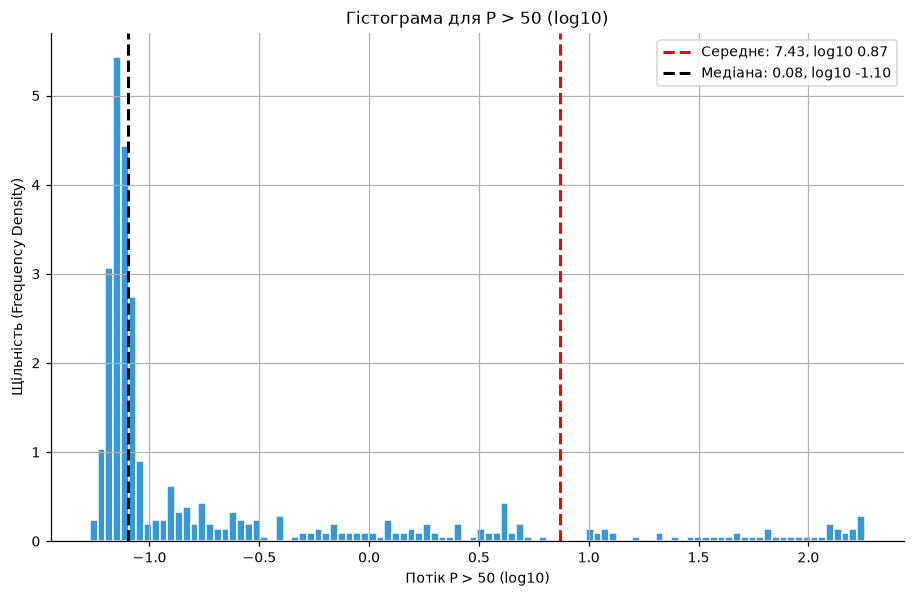

In [70]:
# ВАШ КОД
hist_data = M.loc[M[('P >50', 'mean')]>0, [('P >50', 'mean')]].dropna()
plt.figure(figsize=(10, 6))
plt.hist(
    np.log10(hist_data),
    bins=100,
    color="#3498db",
    edgecolor="white",
    alpha=1,
    density=True,
)
plt.title(
    "Гістограма для P > 50 (log10)"
)
plt.axvline(
    np.log10(M[('P >50', 'mean')].mean()),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Середнє: {M[('P >50', 'mean')].mean():.2f}, log10 {np.log10(M[('P >50', 'mean')].mean()):.2f}",
)
plt.axvline(
    np.log10(M[('P >50', 'mean')].median()),
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Медіана: {M[('P >50', 'mean')].median():.2f}, log10 {np.log10(M[('P >50', 'mean')].median()):.2f}",
)
plt.xlabel("Потік P > 50 (log10)")
plt.ylabel("Щільність (Frequency Density)")
plt.legend()
plt.grid(True)
plt.show()

**Висновок:** Значення потоку P > 50 значною мірою схиляються близько до $10^{-1.2}$, проте присутній довгий хвіст з великих значень, що спотворює гістограму при невикористанні логарифму та спричинює таку розбіжність між середнім (7.43) та медіаною (0.08).

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

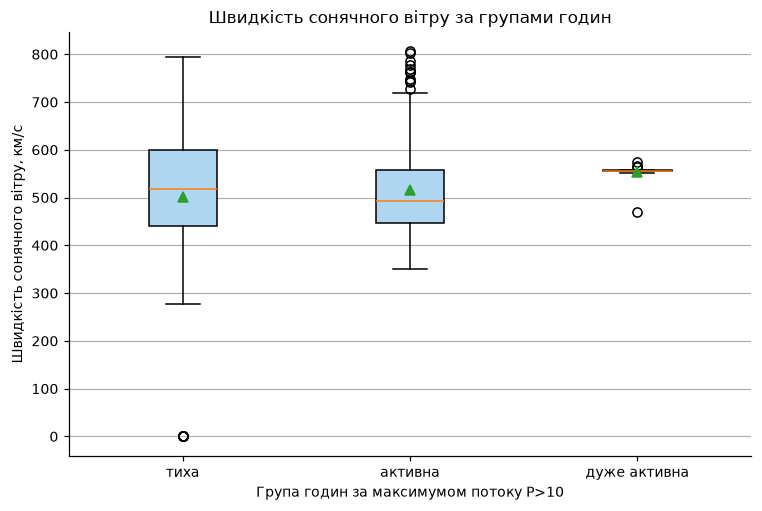

,count,mean,std,min,25%,50%,75%,max
група,,,,,,,,
активна,171.0,515.05848,103.401087,350.0,447.5,492.0,557.0,806.0
дуже активна,18.0,552.944444,21.631873,469.0,555.0,556.0,557.0,575.0
тиха,412.0,501.007282,134.982607,0.0,440.25,517.5,599.0,795.0


In [49]:
# ВАШ КОД
groups = ['тиха', 'активна', 'дуже активна']

data = [M.loc[M['група'] == g, 'SPEED'].dropna() for g in groups]

plt.figure(figsize=(8, 5))
bp = plt.boxplot(data, tick_labels=groups, showmeans=True, patch_artist=True)
for box in bp['boxes']:
    box.set_facecolor('#aed6f1')
plt.title('Швидкість сонячного вітру за групами годин')
plt.xlabel('Група годин за максимумом потоку P>10')
plt.ylabel('Швидкість сонячного вітру, км/с')
plt.grid(True, axis='y')
plt.show()

M.groupby('група')['SPEED'].describe()

**Висновок:** Швидкість вітру не залежить від активності потоку (медіани ~500, медіану 556 та малий розкид для "дуже активної" групи можна пояснити малою вибіркою, прямокутник та вуса лежать приблизно однаково для обох інших груп, у активної він навіть трохи менший)

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Correlation: 0.08856160778553436


/tmp/ipykernel_2286/1323394169.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


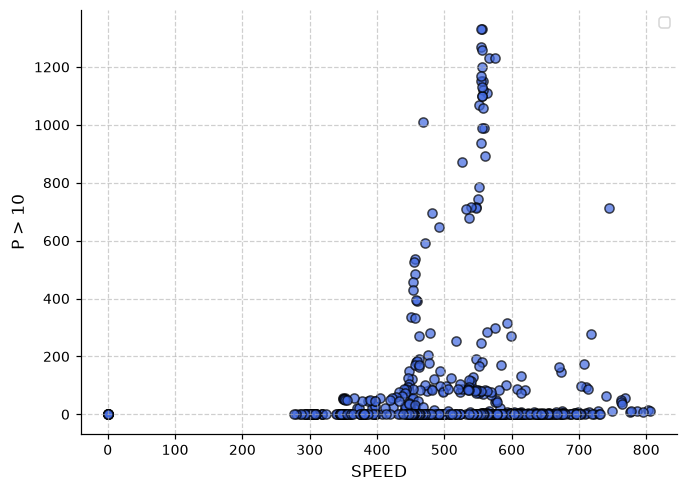

In [50]:
# ВАШ КОД
corr = M[['SPEED', ('P >10', 'max')]].corr().to_numpy()
print(f'Correlation: {corr[0,1]}')

plt.figure(figsize=(7,5))
plt.scatter(
    M["SPEED"], M[('P >10', 'max')], color="royalblue", alpha=0.7, edgecolors="k"
)

plt.xlabel("SPEED", fontsize=11)
plt.ylabel("P > 10", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

**Висновок:** Лінійна кореляція між швидкістю та потоком P>10 відсутня (коеф 0.089), можлива нелінійна кореляція з високими P>10 в районі швидкості 400-500, але це легше пояснити часовим співпадінням

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

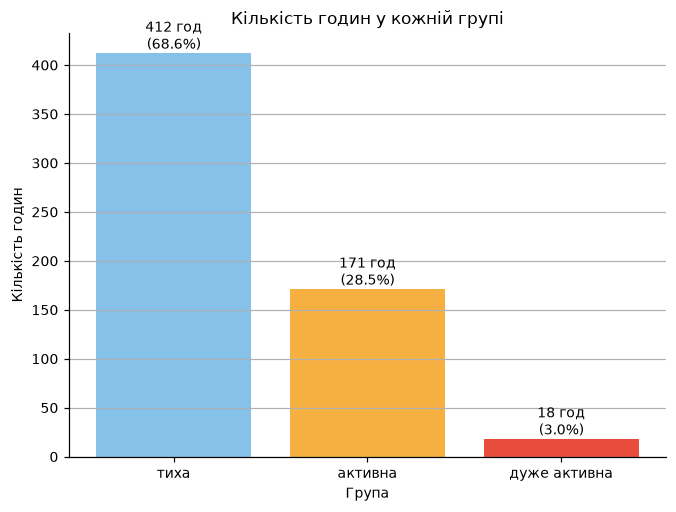

In [51]:
# ВАШ КОД
groups = ['тиха', 'активна', 'дуже активна']
counts = M['група'].value_counts().reindex(groups, fill_value=0)
percentage = counts / counts.sum() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(counts.index, counts.values, color=['#85c1e9', '#f5b041', '#e74c3c'])

for bar, n, p in zip(bars, counts.values, percentage.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{n} год\n({p:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.title('Кількість годин у кожній групі')
plt.xlabel('Група')
plt.ylabel('Кількість годин')
plt.grid(True, axis='y')
plt.show()

**Висновок:** 68.6% годин є тихими, 28.5 активними та 3 дуже активними

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

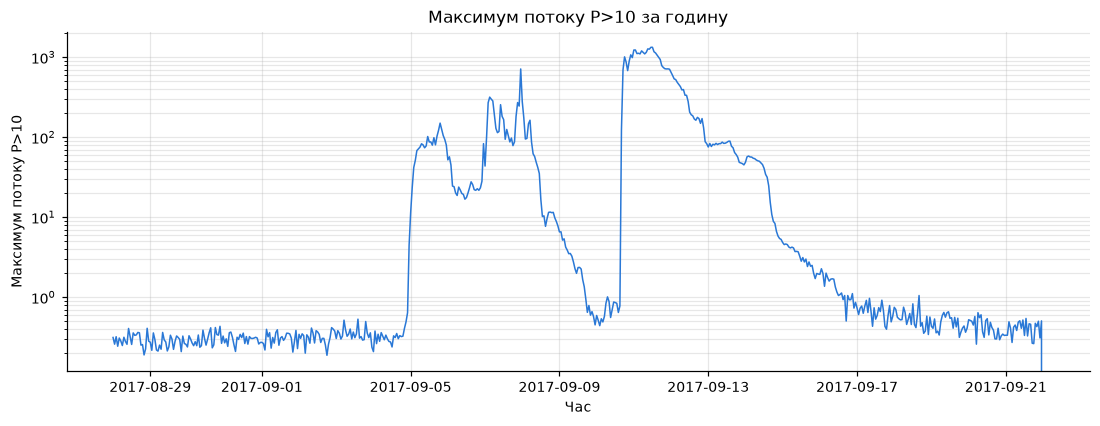

In [52]:
# ВАШ КОД
series = M[('P >10', 'max')]

plt.figure(figsize=(12, 4))
plt.plot(M['ts'], series, color='#2a78d6', linewidth=1)
plt.yscale('log')
plt.title('Максимум потоку P>10 за годину')
plt.xlabel('Час')
plt.ylabel('Максимум потоку P>10')
plt.grid(True, which='both', alpha=0.3)
plt.show()

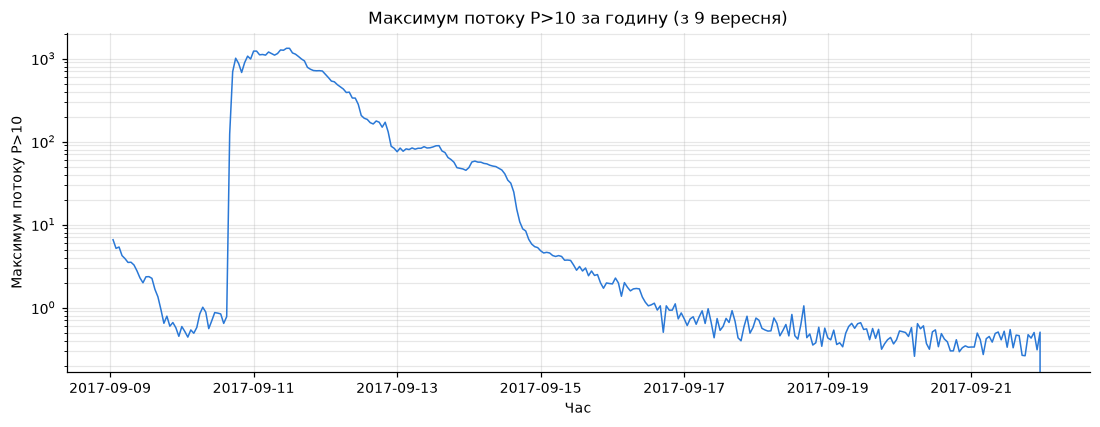

In [53]:
# ВАШ КОД
series = M[('P >10', 'max')].where(M['ts'] > pd.Timestamp("2017-09-09 00:00:00"))

plt.figure(figsize=(12, 4))
plt.plot(M['ts'], series, color='#2a78d6', linewidth=1)
plt.yscale('log')
plt.title('Максимум потоку P>10 за годину (з 9 вересня)')
plt.xlabel('Час')
plt.ylabel('Максимум потоку P>10')
plt.grid(True, which='both', alpha=0.3)
plt.show()

**Висновок:** наявний спалах потоку P>10 з 5 по 9 та з 10 по 15 вересня. Також можна побачити, де саме значення перевищило 1000, а також малий розброс у часі, що пояснює аномалії на інших графіках, особливо там, де було групування по цьому значенню

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

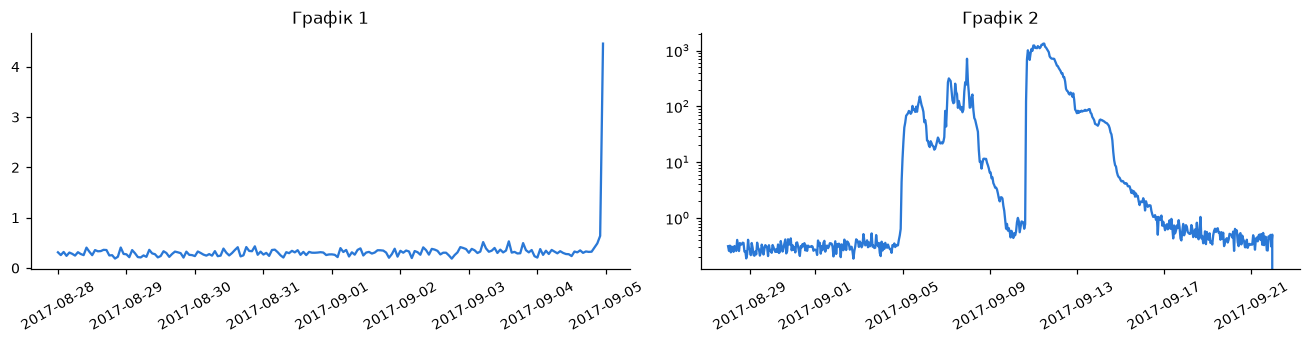

In [54]:
СТОВПЕЦЬ = ('P >10', 'max')   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: 5 вересня стався великий спалах, що далі - невідомо
2. Висновок з другого графіка: від 5 до 9 та від 10 до 15 вересня були два середньо-високі спалахи активності
3. Дві відмінності між ними: перший графік не в log scale та обрізаний, другий - навпаки


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

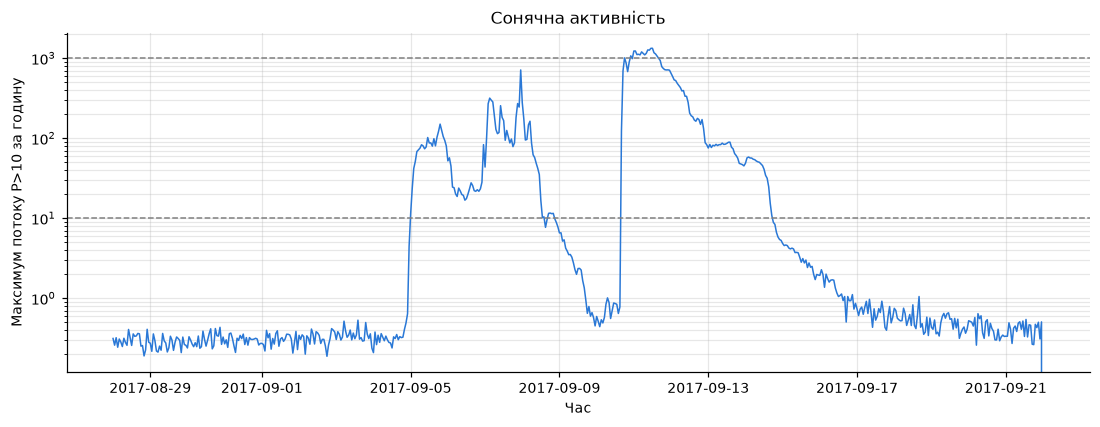

In [55]:
# ВАШ КОД
series = M[('P >10', 'max')]

plt.figure(figsize=(12, 4))
plt.plot(M['ts'], series, color='#2a78d6', linewidth=1)
plt.yscale('log')
plt.axhline(10, color='gray', linestyle='--', linewidth=1)
plt.axhline(1000, color='gray', linestyle='--', linewidth=1)
plt.title('Сонячна активність')
plt.xlabel('Час')
plt.ylabel('Максимум потоку P>10 за годину')
plt.grid(True, which='both', alpha=0.3)
plt.show()

**Відповідь 6.2:** Я використав log scale, бо в іншому випадку всі дані злились би до нуля, окрім великих спалахів. Також я додав горизонтальні лінії на 10 та 1000, щоб відобразити пороги NOAA, які визначали групи

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** значення потоку набагато зручніше відображати в log scale, бо фонова активність набагато нижча за спалахи та повністю ними перебивається, а самі спалахи теж зростають експоненційно, що унеможливлює порівняння в лінійному масштабі двох різних спалахів

**Спостереження 2:** максимальне значення ледве перетнуло позначку 1000 та тривало дуже мало (менше одного дня), що спричинило малу вибірку для групи 'дуже активно'

**Спостереження 3:** відсутня лінійна кореляція між швидкістю сонячного вітру та значенням потоку, аномалію на скатерплоті можна пояснити часовим збігом


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [56]:
# ВАШ КОД
M = M.sort_values('ts').reset_index(drop=True)

active = M['група'].isin(['активна', 'дуже активна'])
runs = (active != active.shift()).cumsum()

lengths = active.groupby(runs).sum()
starts = M.loc[active, 'ts'].groupby(runs).min()
ends = M.loc[active, 'ts'].groupby(runs).max()

active_runs = pd.DataFrame({'годин': lengths, 'від': starts, 'до': ends})
active_runs = active_runs[active_runs['годин'] > 0].sort_values('годин', ascending=False)

print('Найдовша неперервна серія активних годин:', active_runs['годин'].iloc[0])
print('Від:', active_runs['від'].iloc[0], 'до:', active_runs['до'].iloc[0])
print()
print(active_runs)

Найдовша неперервна серія активних годин: 98
Від: 2017-09-10 16:00:00 до: 2017-09-14 17:00:00

       годин                 від                  до
група                                               
6         98 2017-09-10 16:00:00 2017-09-14 17:00:00
2         87 2017-09-05 00:00:00 2017-09-08 14:00:00
4          4 2017-09-08 17:00:00 2017-09-08 20:00:00


**Відповідь 7.2:** Якщо рахувати "активна" як "дуже активна" також, то найдовша серія тривала 98 годин, а саме з 10 вересня 16:00 по 14 вересня 17:00 

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [57]:
ІНСТРУМЕНТИ_ШІ = 'Gemini, Kilo code (deepseek v4.1 flash)'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'синтаксис',
    'етап 4, об’єднання таблиць':                 'синтаксис',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'ні',
    'етапи 6–7, порівняння графіків і спостереження': 'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'відповідність коду опису проблеми, відсутність \
непотрібних речей (імпортів, декорацій, тексту, інших ознак ШІ-слопу) \
у коді, зрозумілість коду'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [58]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Білоусов Михайло
інструменти:                                   Gemini, Kilo code (deepseek v4.1 flash)
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об’єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                ні
етапи 6–7, порівняння графіків і спостереження: код, перевірено
------------------------------------------------------------------------------
перевірено автором:
відповідність коду опису проблеми, відсутність непотрібних речей (імпортів, декорацій, тексту, інших ознак ШІ-слопу) у коді, зрозумілість коду
Автор підтверджує, що може пояснити кожен рядок коду під час захисту.


---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [59]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (601, 21)


In [60]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
